# 01 — Features físicas y prior logístico jerárquico

Este notebook explica la **primera mitad del modelo bayesiano**: cómo pasamos de la información del accidente (posición `x_E`, velocidades `v_plane`, `v_wind`, `v_drift`, testigos) a una distribución *prior* sobre la celda Z donde se encuentran los restos.

## La idea en una frase

$$\pi_j(\beta, \tau) = \text{softmax}_j\bigl(\eta_j(\beta, \tau)\bigr)$$

donde $\eta_j$ es un *predictor lineal* (forma logística-softmax) cuyos coeficientes $\beta$ y latencias $\tau$ tienen **prior Bayesiano**. La gracia es que más adelante (notebook 03) actualizaremos la posterior de $\beta$ con las observaciones de misiones — no asumimos que la física es determinista.

Código fuente:
- [`modeling/features.py`](../modeling/features.py)
- [`modeling/priors_logistic.py`](../modeling/priors_logistic.py)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt
from update_version.simulator.grid import load_grid
from update_version.modeling.features import (
    ACCIDENT_POINT, V_PLANE, V_WIND, V_DRIFT, ALPHA_WIND,
    expected_landing, trajectory_axes, cell_distances, evaluate_pi,
)
from update_version.modeling.priors_logistic import PRIORS

grid = load_grid('../data/grid_dataset.csv')
print(f'Grid: {grid.Nx} x {grid.Ny} = {grid.n_cells} cells')

Grid: 50 x 35 = 1750 cells


## 1. Punto esperado de aterrizaje $\mu(\tau_{\text{fall}}, \tau_{\text{drift}})$

El profesor nos da:
- Punto de explosión: $x_E = (7, 20)$
- Velocidad del avión: $v_{\text{plane}} = (6, -3.5)$ — sobre todo hacia el este, ligeramente sur
- Viento: $v_{\text{wind}} = (-1, -1.5)$ — oeste-sur
- Corriente: $v_{\text{drift}} = (0.5, -1.5)$ — sur, ligeramente este

Modelamos el desplazamiento como:
$$\mu(\tau) = x_E + \tau_{\text{fall}} \cdot (v_{\text{plane}} + \alpha_{\text{wind}} v_{\text{wind}}) + \tau_{\text{drift}} \cdot v_{\text{drift}}$$

con $\alpha_{\text{wind}} = 0.5$ fijo (acoplamiento viento-objeto en caída). Los dos $\tau$ son **parámetros Bayesianos** con prior LogNormal$(0, 0.3)$ centrado en 1.

El predictor lineal es:
$$\eta_j(\beta, \tau) = \beta_0 + \beta_1 d_\text{long}(j) + \beta_2 d_\text{trans}(j) - \beta_3 d_\text{long}^2(j) - \beta_4 d_\text{trans}^2(j)$$

donde $d_\text{long}, d_\text{trans}$ son las distancias proyectadas sobre el eje de trayectoria y su perpendicular. Las componentes cuadráticas dan una forma gaussiana; las lineales permiten desplazar el pico (capturan los testigos).

mu(tau=1, 1) = [13.   14.25]
d_norm (trayectoria) = [ 0.791285  -0.6114475]
n_norm (perpendicular) = [0.6114475 0.791285 ]


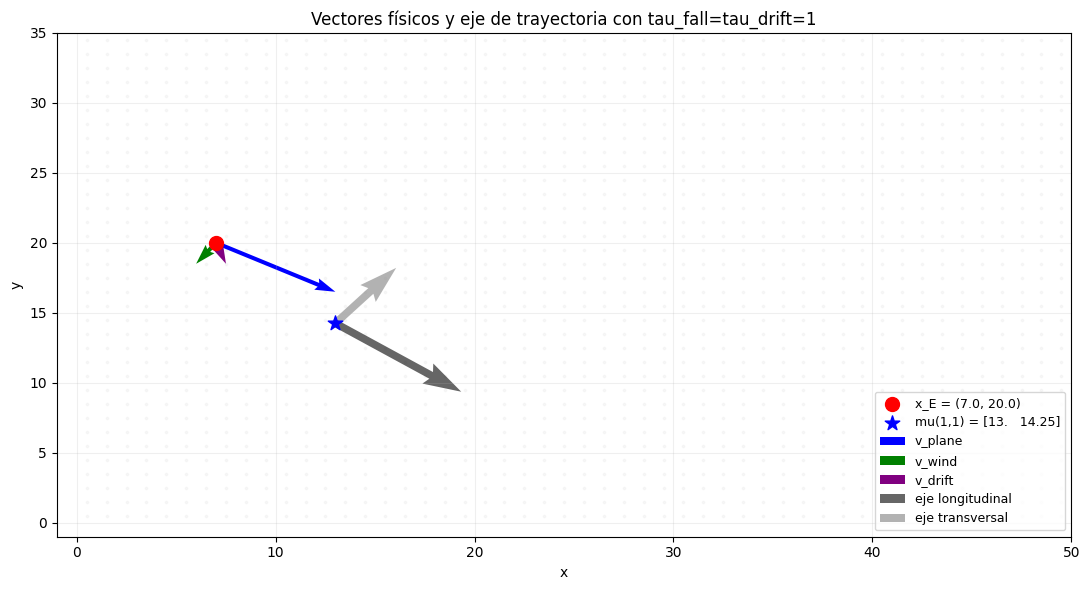

In [2]:
# Visualizar mu y los ejes para tau=1
mu = expected_landing(1.0, 1.0)
d_norm, n_norm = trajectory_axes()
print(f'mu(tau=1, 1) = {mu}')
print(f'd_norm (trayectoria) = {d_norm}')
print(f'n_norm (perpendicular) = {n_norm}')

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(grid.x, grid.y, s=3, alpha=0.15, color='lightgray')
ax.scatter(*ACCIDENT_POINT, color='red', s=100, label=f'x_E = {tuple(ACCIDENT_POINT)}', zorder=5)
ax.scatter(*mu, color='blue', s=120, marker='*', label=f'mu(1,1) = {mu.round(2)}', zorder=5)
ax.quiver(*ACCIDENT_POINT, *V_PLANE, angles='xy', scale_units='xy', scale=1, color='blue', label='v_plane', width=0.004)
ax.quiver(*ACCIDENT_POINT, *V_WIND, angles='xy', scale_units='xy', scale=1, color='green', label='v_wind', width=0.004)
ax.quiver(*ACCIDENT_POINT, *V_DRIFT, angles='xy', scale_units='xy', scale=1, color='purple', label='v_drift', width=0.004)
ax.quiver(*mu, *(8*d_norm), angles='xy', scale_units='xy', scale=1, color='black', label='eje longitudinal', alpha=0.6)
ax.quiver(*mu, *(5*n_norm), angles='xy', scale_units='xy', scale=1, color='gray', label='eje transversal', alpha=0.6)
ax.set_xlim(-1, grid.Nx); ax.set_ylim(-1, grid.Ny); ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Vectores físicos y eje de trayectoria con tau_fall=tau_drift=1')
ax.legend(loc='lower right', fontsize=9); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

## 2. Coordenadas por celda: $d_\text{long}$ y $d_\text{trans}$

Cada celda $j$ se describe por su distancia *firmada* al punto esperado, proyectada sobre los dos ejes. Esto sustituye las coordenadas crudas $(x_j, y_j)$ por dos features que tienen interpretación física directa.

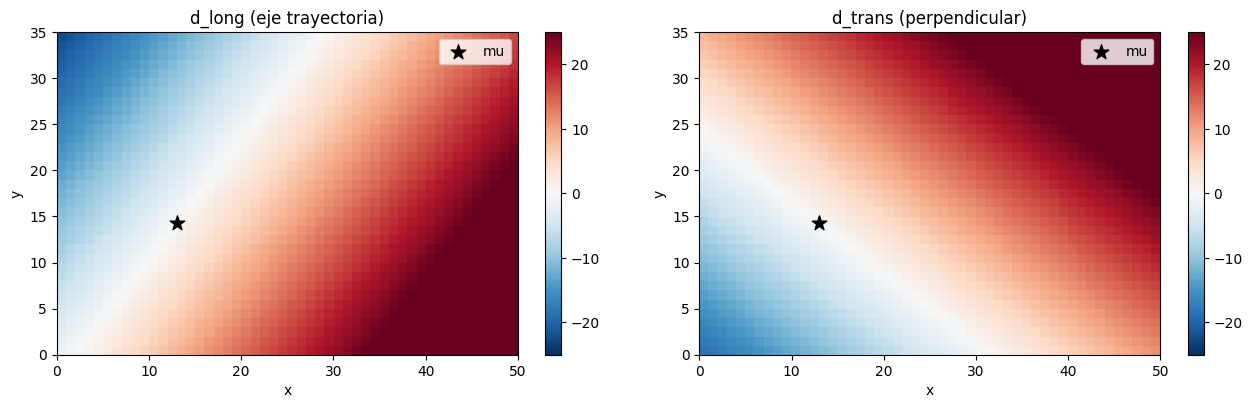

In [3]:
d_long, d_trans = cell_distances(grid.x, grid.y, tau_fall=1.0, tau_drift=1.0)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, vals, title in zip(axes, [d_long, d_trans], ['d_long (eje trayectoria)', 'd_trans (perpendicular)']):
    im = ax.imshow(grid.reshape_2d(vals), origin='lower', cmap='RdBu_r',
                   extent=[0, grid.Nx, 0, grid.Ny], vmin=-25, vmax=25)
    ax.scatter(*mu, color='black', marker='*', s=120, label='mu')
    ax.set_title(title); ax.set_xlabel('x'); ax.set_ylabel('y'); ax.legend()
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## 3. Ejemplo: $\pi_j$ para una sola muestra de $(\beta, \tau)$

Sólo con propósito didáctico: fijamos valores manuales que produzcan un pico Gaussiano alrededor de $\mu$ con $\sigma_\text{long}=6$ y $\sigma_\text{trans}=4$.

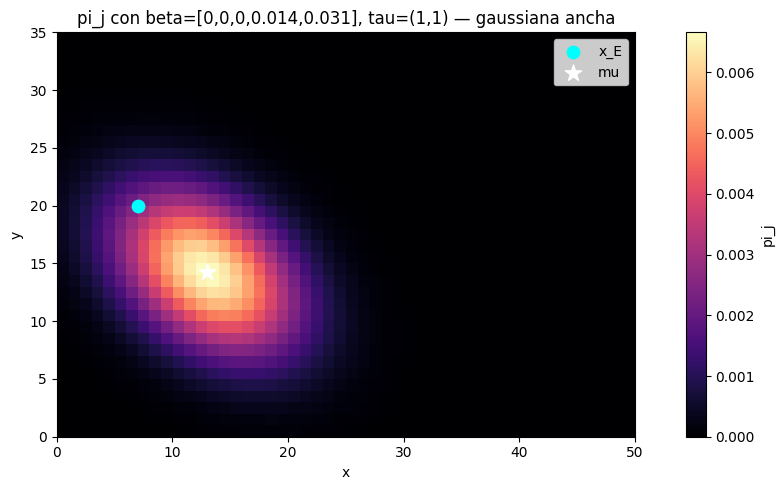

Suma = 1.0000  |  Max = 0.0067  |  Pico en celda 712


In [4]:
sigma_long, sigma_trans = 6.0, 4.0
beta_demo = np.array([0.0, 0.0, 0.0, 1/(2*sigma_long**2), 1/(2*sigma_trans**2)])
pi_demo = evaluate_pi(beta_demo, 1.0, 1.0, grid.x, grid.y)

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(grid.reshape_2d(pi_demo), origin='lower', cmap='magma', extent=[0, grid.Nx, 0, grid.Ny])
ax.scatter(*ACCIDENT_POINT, color='cyan', s=80, label='x_E')
ax.scatter(*mu, color='white', marker='*', s=150, label='mu')
ax.set_title(f'pi_j con beta=[0,0,0,{beta_demo[3]:.3f},{beta_demo[4]:.3f}], tau=(1,1) — gaussiana ancha')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.legend()
plt.colorbar(im, ax=ax, fraction=0.046, label='pi_j')
plt.tight_layout(); plt.show()
print(f'Suma = {pi_demo.sum():.4f}  |  Max = {pi_demo.max():.4f}  |  Pico en celda {pi_demo.argmax()}')

## 4. Las 8 variantes de prior

Variamos en 3 ejes (forma, testigos, informatividad). Para cada variante mostramos el **prior predictivo** $E_{\beta, \tau \sim \text{prior}}[\pi_j]$ (estimado por Monte Carlo).

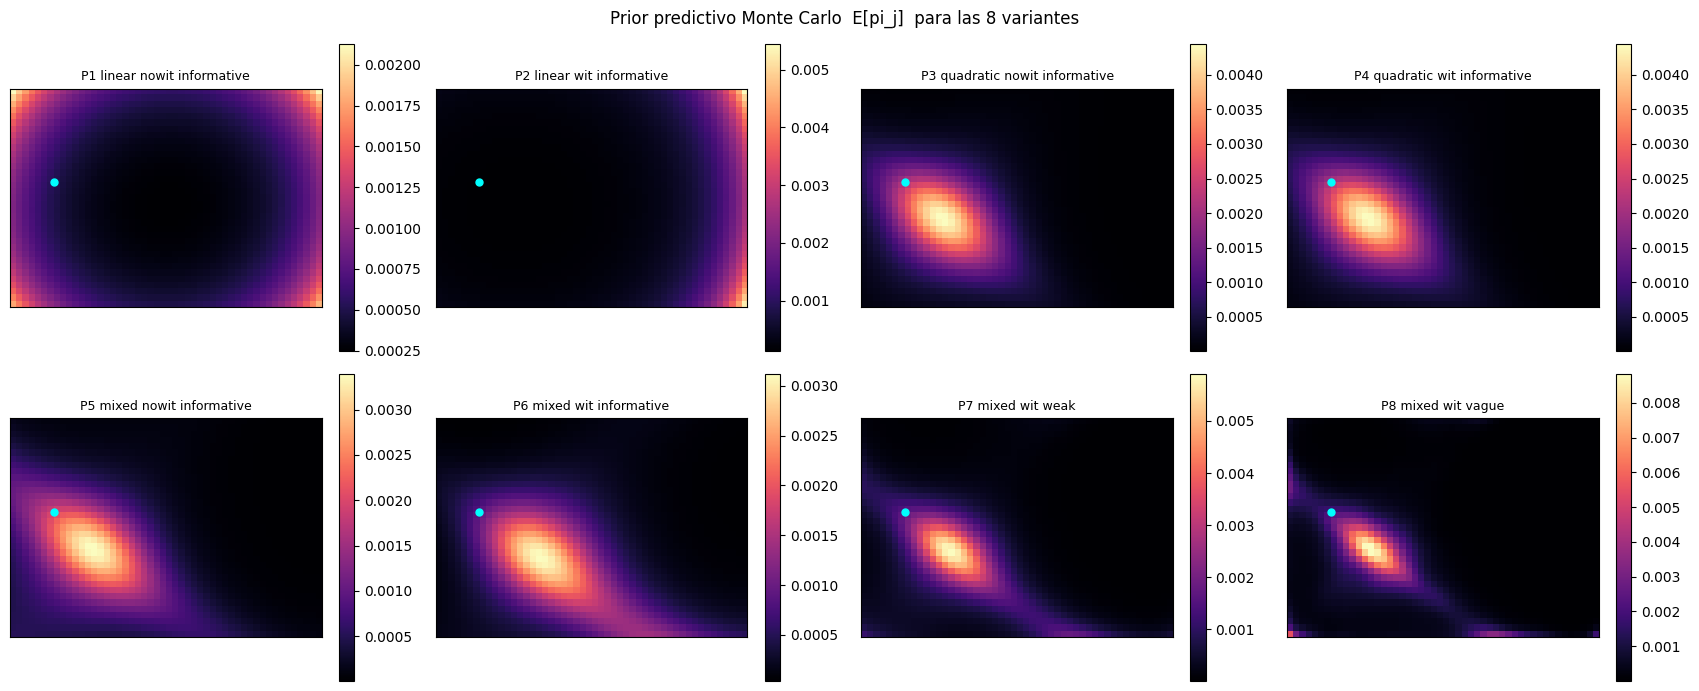

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(17, 7))
for ax, (name, spec) in zip(axes.flat, PRIORS.items()):
    pi_mean = spec.prior_predictive_pi(grid.x, grid.y, n_samples=800, seed=0)
    im = ax.imshow(grid.reshape_2d(pi_mean), origin='lower', cmap='magma',
                   extent=[0, grid.Nx, 0, grid.Ny])
    ax.scatter(*ACCIDENT_POINT, color='cyan', s=25)
    ax.set_title(name.replace('_', ' '), fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle('Prior predictivo Monte Carlo  E[pi_j]  para las 8 variantes')
plt.tight_layout(); plt.show()

**Cómo leer el grid:**
- *Linear no-witnesses* (P1): pi sin pico claro — `exp(linear)` no concentra masa.
- *Quadratic* (P3, P4): pico bien definido alrededor de $\mu$, sin desplazamiento por testigos.
- *Mixed* (P5–P8): pico + sesgo lineal. Con testigos (P6) el pico se desplaza un poco según witness 1/2.
- *Weak* (P7) / *Vague* (P8): priors más planos, más cobertura del grid → más robusto a un mal modelo físico, pero menos informativo a priori.

## 5. Hiperparámetros que controlan cada prior

Cada `PriorSpec` expone los `mean` y `sigma` que se pasarán al PyMC model. Veámoslos:

In [6]:
import pandas as pd
rows = []
for name, spec in PRIORS.items():
    rows.append({
        'name': name,
        'form': spec.form,
        'witnesses': spec.witnesses,
        'info': spec.info,
        'b1_active': spec.b1_active, 'b1_mean': spec.b1_mean, 'b1_sigma': round(spec.b1_sigma, 3),
        'b3_active': spec.b3_active, 'b3_sigma': round(spec.b3_sigma, 4),
        'tau_sigma': spec.tau_fall_sigma,
    })
pd.DataFrame(rows)

,name,form,witnesses,info,b1_active,b1_mean,b1_sigma,b3_active,b3_sigma,tau_sigma
0,P1_linear_nowit_informative,linear,False,informative,True,0.0,0.1,False,0.0139,0.3
1,P2_linear_wit_informative,linear,True,informative,True,0.1,0.1,False,0.0139,0.3
2,P3_quadratic_nowit_informative,quadratic,False,informative,False,0.0,0.1,True,0.0139,0.3
3,P4_quadratic_wit_informative,quadratic,True,informative,False,0.1,0.1,True,0.0139,0.3
4,P5_mixed_nowit_informative,mixed,False,informative,True,0.0,0.1,True,0.0139,0.3
5,P6_mixed_wit_informative,mixed,True,informative,True,0.1,0.1,True,0.0139,0.3
6,P7_mixed_wit_weak,mixed,True,weak,True,0.1,0.3,True,0.0417,0.3
7,P8_mixed_wit_vague,mixed,True,vague,True,0.1,1.0,True,0.1389,0.3


## Siguiente notebook

[`02_detection_models.ipynb`](02_detection_models.ipynb) — los cuatro modelos de detección $\rho_{t,j}(d, r, e)$ que combinaremos con cada prior.